# VHH HEFT predictions — NNLO QCD

This notebook computes theoretical predictions for **double-Higgs production in
association with a vector boson** ($W^\pm HH$ and $ZHH$) in the **Higgs Effective
Field Theory (HEFT)** at **LO** in the EFT expansion, and **NNLO QCD**, for the LHC at 13.6 or 14 TeV.

All numbers come from **closed-form formulas** evaluated against coefficients
bundled in `data/HEFT/` — there is no Monte Carlo run and no fit to perform here. You
pick a point in Wilson-coefficient ($\kappa$) space, and get back a cross section
with uncertainties.

> **Install once** with `pip install -e ".[notebook]"` (package only), then open this
> notebook from the repo root. Restart the kernel after editing `vhh_predict/`.

> For **SMEFT** Wilson coefficients use the companion notebook
> [`vhh_prediction_SMEFT.ipynb`](vhh_prediction_SMEFT.ipynb).

## Contents

| § | What it does | Main output |
|---|---|---|
| Setup | Editable install check + imports | — |
| 1 | Process, energy, output flags | — |
| 2 | Spot check: $\kappa$ point | results table (+ simulation if available) |
| 3 | Scan one $\kappa$ axis and plot | `scan_data` + PNGs (+ optional `.txt`) |
| 4 | Joint multi-axis grid scan | one `results/points/*_x_*.txt` |
| 5 | Wilson benchmark tables | `results/tables/wilson_tables.tex` |

See [README.md](README.md) for an overview; `AGENTS.md` for the package API.


## Setup

Requires an editable install from the repo root (defined in `pyproject.toml`):

```bash
pip install -e ".[notebook]"
```

Then `import vhh_predict` works — notebooks do **not** modify `sys.path`.
Restart the kernel after changing package code.


In [ ]:
from vhh_predict.analysis import package_root

REPO_ROOT = package_root()
if not (REPO_ROOT / "data" / "HEFT").is_dir() or not (REPO_ROOT / "vhh_predict").is_dir():
    raise RuntimeError(
        f"Expected 'data/HEFT/' and 'vhh_predict/' under {REPO_ROOT}.\n"
        "Install from the repo root:  pip install -e \".[notebook]\"\n"
        "Then start Jupyter from that same directory."
    )

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from vhh_predict import (
    CHANNELS,
    TABLE_ENERGIES_TEV,
    WILSON_INTERVALS,
    build_channel_tables,
    latex_wilson_tables_for_process,
    load_analysis,
    plots_dir,
    resolve_scan_axis,
    scan_and_save,
    scan_axes,
    scan_grid_and_save,
    tables_dir,
)
from vhh_predict.core import spot_check_caption, spot_check_table
from vhh_predict.plot_style import (
    default_plot_title,
    plot_style_with_layout,
    scan_plot_filename_stem,
)
from vhh_predict.plots import (
    plot_sigma_nnlo_and_enhancement_nnlo,
    plot_sigma_nnlo_and_kfactor,
)
from vhh_predict.tables import KAPPA_PLAIN, ZHH_TABLE_GROUPS

PLOTS_DIR = plots_dir()
TABLES_DIR = tables_dir()
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repo root: {REPO_ROOT}")


## 1. Configuration

| Variable | Meaning |
|----------|---------|
| `PROCESS` | `"WplusHH"`, `"WminusHH"`, or `"ZHH"` |
| `ENERGY_TEV` | `13.6` or `14.0` |
| `COMPARE_SIMULATION` | Compare to bundled simulation central values in §2 only |
| `UNCERTAINTIES_AS_PERCENT` | Print uncertainties as % (`False` → fb) |
| `SAVE_SCAN_POINTS` | Write §3 / §4 scan tables to `results/points/` |
| `SAVE_PLOTS` | Write §3 plot PNGs to `results/plots/` |
| `SIGMA_INSET` | Zoom inset on $\sigma_{\mathrm{NNLO}}$ panels (`True` / `False`) |
| `LEGEND_LOC` | Top-panel legend corner: `upper left`, `upper right`, `lower left`, `lower right` |
| `INSET_LOC` | Inset corner (same choices); ignored when `SIGMA_INSET=False` |

Wilson coefficients ($\kappa$) → **§2** (spot-check point). Scan background κ → **§3** and **§4** (`FIXED_KAPPA`). Scan range → **§3**.

**Wilson-coefficient 95% CL intervals** (Table 2, HEFT uncertainty note; code: `WILSON_INTERVALS` in `vhh_predict/tables.py`):

| Coefficient | Min | SM | Max |
|-------------|-----|----|-----|
| $\kappa_\lambda$ | −0.7 | 1 | 6.1 |
| $\kappa_W$ | 0.8 | 1 | 1.2 |
| $\kappa_Z$ | 0.9 | 1 | 1.2 |
| $\kappa_{2W}$ | 0.7 | 1 | 1.3 |
| $\kappa_{2Z}$ | 0.7 | 1 | 1.3 |
| $\kappa_t$ | 0.8 | 1 | 1.2 |


In [2]:
# ---- Process and collision energy ----
PROCESS = "ZHH"        # "WplusHH", "WminusHH", or "ZHH"
ENERGY_TEV = 14.0       # 13.6 or 14.0

# ---- Output flags ----
COMPARE_SIMULATION = True
UNCERTAINTIES_AS_PERCENT = True 
SAVE_SCAN_POINTS = True
SAVE_PLOTS = True

# ---- Plot layout ----
SIGMA_INSET = False
LEGEND_LOC = "lower right"   # upper left | upper right | lower left | lower right
INSET_LOC = "upper left"     # same; ignored when SIGMA_INSET=False

PLOT_STYLE = plot_style_with_layout(
    legend_loc=LEGEND_LOC,
    inset_loc=INSET_LOC,
    sigma_inset=SIGMA_INSET,
)

analysis = load_analysis(PROCESS, ENERGY_TEV)
nn_label = analysis.nnlo_label

print(f"{PROCESS} @ {ENERGY_TEV} TeV  |  scan axes: {', '.join(scan_axes(PROCESS))}")


ZHH @ 14.0 TeV  |  scan axes: kappa_lambda, kappa_z, kappa_2z, kappa_t


## 2. Spot check

Set **`KAPPA`** — the Wilson-coefficient point **for the table below only** (independent of §3–§4 scans).

| Process | `KAPPA` tuple | SM |
|---------|---------------|-----|
| `WplusHH`, `WminusHH` | `(κ_λ, κ_W, κ_{2W})` — **3 numbers** | all `1.0` |
| `ZHH` | `(κ_λ, κ_Z, κ_{2Z}, κ_t)` — **4 numbers** | all `1.0` |

The table lists **HEFT** predictions with scale and PDF+αs uncertainties.
When `COMPARE_SIMULATION=True` (§1), **Simulation** central values from
`data/HEFT/.../Simulation/` are shown with **Δ vs simulation** (percent difference vs HEFT).
Missing simulation points show `—`.

In [3]:
# Wilson-coefficient point (SM: all 1.0)
KAPPA = (1.0, 1.0, 1.0, 1.0)  # ZHH example: (3.0, 1.0, 1.0, 1.0) → κ_λ = 3

display(Markdown(f"### {spot_check_caption(analysis, KAPPA)}"))
display(
    spot_check_table(
        analysis,
        KAPPA,
        as_percent=UNCERTAINTIES_AS_PERCENT,
        compare_simulation=COMPARE_SIMULATION,
    )
)


### ZHH @ 14 TeV — κ = (1, 1, 1, 1)

,Quantity,HEFT,Scale (+/−),PDF+αs,Simulation,Δ vs simulation
0,σ_LO [fb],0.305501,+0.99% / −1.22%,±2.04%,0.308516,-0.98%
1,σ_NNLO [fb],0.417333,+3.42% / −2.69%,±1.89%,0.420441,-0.74%
2,σ_HEFT/σ_SM (LO),1,—,—,—,—
3,σ_HEFT/σ_SM (NNLO),1,—,—,—,—
4,K,1.36606,—,—,1.36279,+0.24%


## 3. Scan and plots

Vary **one** Wilson coefficient, then build the two default two-panel figures.

- `FIXED_KAPPA` — full κ tuple; **non-scanned** components stay at these values (independent of §2 `KAPPA`)
- `scan_axis` — which κ to vary (see `scan_axes` printed in §1)
- `scan_vmin`, `scan_vmax` — scan / plot window (Wilson interval printed below as reference)
- `scan_n_points` — resolution (400 → smooth curves)

`uncertainties=True` keeps PDF/scale bands in memory for plotting (not written to disk).
Set `SAVE_SCAN_POINTS=True` in §1 to also write
`results/points/{Process}_{energy}TeV_{axis}.txt`.

Two figures: $\sigma_{\mathrm{NNLO}}$ + $K$, and
$\sigma_{\mathrm{NNLO}}$ + $\sigma_{\mathrm{HEFT}}/\sigma_{\mathrm{SM}}$ (NNLO).
Saved to `results/plots/` when `SAVE_PLOTS=True` (§1).

| Panel | Shows |
|---|---|
| $\sigma_{\mathrm{NNLO}}$ | NNLO cross section vs. the scanned $\kappa$, with PDF+$\alpha_s$ and scale bands |
| $\sigma_{\mathrm{LO}}$ | Same, at LO |
| $K$ | $\sigma_{\mathrm{NNLO}}/\sigma_{\mathrm{LO}}$ |
| $\sigma_{\mathrm{HEFT}}/\sigma_{\mathrm{SM}}$ (LO) | Enhancement over the SM point, at LO |
| $\sigma_{\mathrm{HEFT}}/\sigma_{\mathrm{SM}}$ (NNLO) | Enhancement over the SM point, at NNLO |


Wilson interval (95% CL, §5 tables): [0.8, 1.2]  (κ_t)
Scan / plot window:                  [0.85, 1.15]
Saved /Users/michalryczkowski/Documents/Programming/GitHub/VHH-NNLO/results/points/ZHH_14TeV_kappa_t.txt


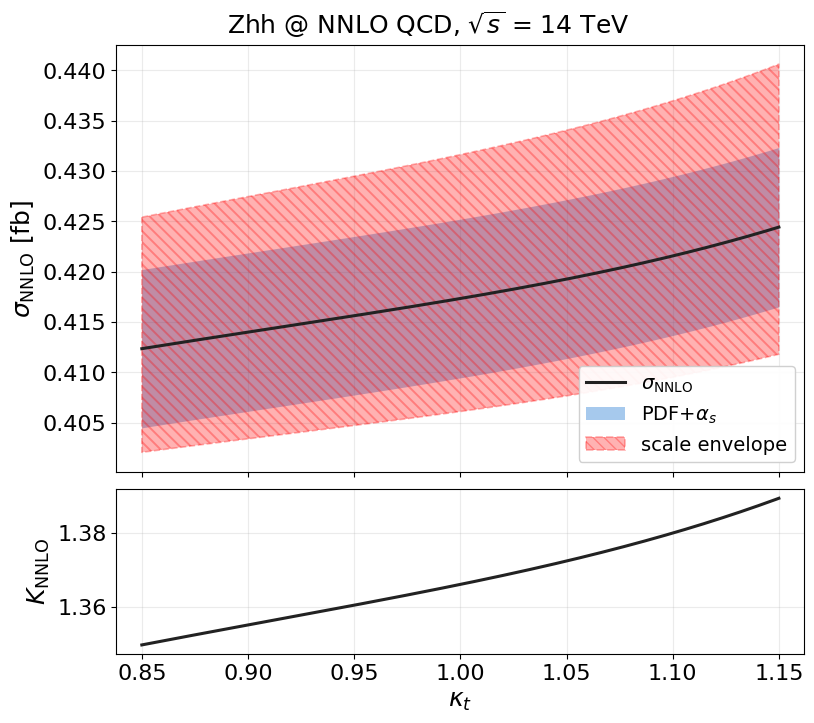

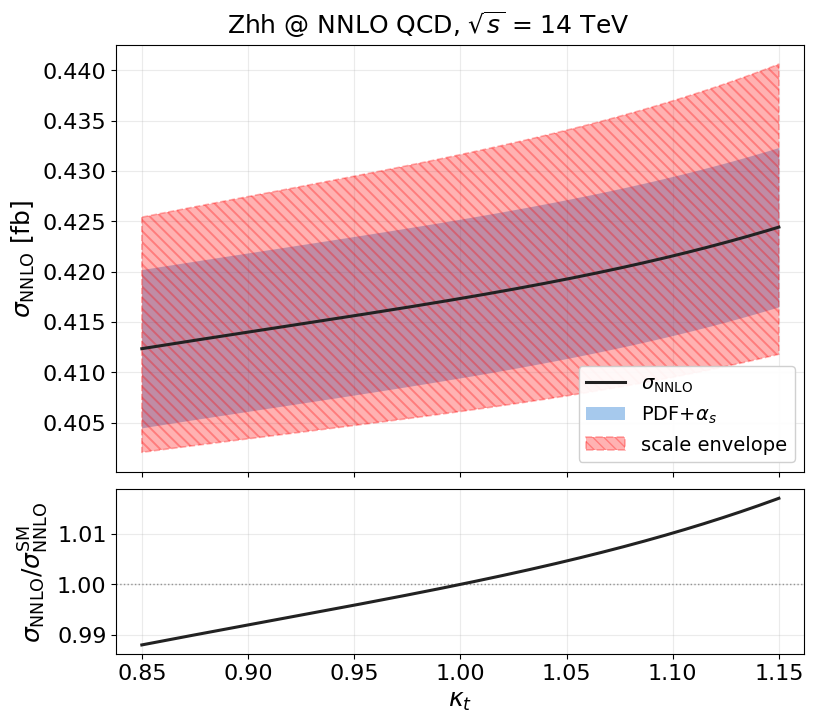

In [4]:
# Tuple order (must match PROCESS from §1):
#   WplusHH / WminusHH — (kappa_lambda, kappa_w, kappa_2w)
#   ZHH                — (kappa_lambda, kappa_z, kappa_2z, kappa_t)
# Scan one of: see scan_axes printed in §1.

FIXED_KAPPA = (1.0, 1.0, 1.0, 1.0)  # values for components NOT on scan_axis (SM: all 1.0)

scan_axis = "kappa_t"              # which κ to vary along the x-axis
scan_vmin, scan_vmax = 0.85, 1.15  # scan / plot window (Wilson interval below; §1 table)
scan_n_points = 400                # grid resolution

wilson_lo, wilson_hi = WILSON_INTERVALS[scan_axis]
print(f"Wilson interval (95% CL, §5 tables): [{wilson_lo:g}, {wilson_hi:g}]  ({KAPPA_PLAIN[scan_axis]})")
print(f"Scan / plot window:                  [{scan_vmin:g}, {scan_vmax:g}]")
if scan_vmin < wilson_lo or scan_vmax > wilson_hi:
    print("  (scan window extends outside Wilson table bounds)")

scan_data, scan_points_file = scan_and_save(
    analysis,
    scan_axis,
    vmin=scan_vmin,
    vmax=scan_vmax,
    fixed_kappa=FIXED_KAPPA,
    n_points=scan_n_points,
    uncertainties=True,      # PDF/scale bands on sigma panels
    save=SAVE_SCAN_POINTS,
)
if SAVE_SCAN_POINTS:
    print(f"Saved {scan_points_file}")

_, scan_x_key = resolve_scan_axis(PROCESS, scan_axis)
plot_title = default_plot_title(PROCESS, ENERGY_TEV, nn_label)
prefix = scan_plot_filename_stem(PROCESS, ENERGY_TEV, scan_x_key, scan_vmin, scan_vmax)

_nnlo_kw = dict(
    style=PLOT_STYLE,
    nnlo_label=nn_label,
    xmin=scan_vmin,
    xmax=scan_vmax,
    save=SAVE_PLOTS,
)

plot_sigma_nnlo_and_kfactor(
    scan_data,
    title=plot_title,
    sigma_inset=SIGMA_INSET,
    output=PLOTS_DIR / f"{prefix}_sigma_nnlo_K.png",
    **_nnlo_kw,
)
plt.show()

plot_sigma_nnlo_and_enhancement_nnlo(
    scan_data,
    title=plot_title,
    sigma_inset=SIGMA_INSET,
    show_enhancement_uncertainty=False,
    output=PLOTS_DIR / f"{prefix}_sigma_nnlo_sigmaSM_{nn_label}.png",
    **_nnlo_kw,
)
plt.show()


## 4. Joint multi-axis scan (Cartesian grid)

Vary **all** listed axes **at once** (Cartesian product) and write **one** `.txt`.

- `FIXED_KAPPA` — full κ tuple; **non-scanned** components stay at these values
- `BATCH_SCAN_AXES` — axes to vary jointly (subset of `scan_axes(PROCESS)`)
- `BATCH_SCAN_WINDOWS` — optional `{axis: (vmin, vmax)}`; omitted axes use `WILSON_INTERVALS`
- `BATCH_SCAN_N_POINTS` — points **per axis** (2 axes × 40 → 1600 rows)

File: `results/points/{Process}_{energy}TeV_{axis1}_x_{axis2}.txt` when `SAVE_SCAN_POINTS=True`.
Set `BATCH_SCAN_AXES = ()` to skip.


In [ ]:
FIXED_KAPPA = (1.0, 1.0, 1.0, 1.0)  # values for components NOT being scanned (SM: all 1.0)

# Axes to vary jointly (ZHH example)
BATCH_SCAN_AXES = (
    "kappa_lambda",
    "kappa_z",
    # "kappa_2z",
    # "kappa_t",
)
BATCH_SCAN_N_POINTS = 40  # per axis → 40×40 = 1600 points for 2 axes

BATCH_SCAN_WINDOWS = {
    # "kappa_lambda": (-1.0, 4.0),
    # "kappa_t": (0.9, 1.1),
}

if BATCH_SCAN_AXES:
    scan_data, path = scan_grid_and_save(
        analysis,
        BATCH_SCAN_AXES,
        windows=BATCH_SCAN_WINDOWS or None,
        n_points=BATCH_SCAN_N_POINTS,
        fixed_kappa=FIXED_KAPPA,
        save=SAVE_SCAN_POINTS,
        uncertainties=False,
    )
    n_total = len(next(iter(scan_data.values())))
    print(f"Joint grid scan: {len(BATCH_SCAN_AXES)} axes × {BATCH_SCAN_N_POINTS} pts → {n_total} points")
    for axis in BATCH_SCAN_AXES:
        x_key = resolve_scan_axis(PROCESS, axis)[1]
        lo, hi = (BATCH_SCAN_WINDOWS or {}).get(axis) or WILSON_INTERVALS[x_key]
        print(f"  {KAPPA_PLAIN[x_key]}  [{lo:g}, {hi:g}]")
    print(f"  →  {path if SAVE_SCAN_POINTS else '(not saved)'}")
else:
    print("Joint scan skipped (BATCH_SCAN_AXES is empty).")


## 5. Wilson-coefficient benchmark tables

Independent of §1–4 above — always evaluates **all three channels**
($W^+HH$, $W^-HH$, $ZHH$) at **both** energies (13.6 and 14 TeV).

For each channel, $\sigma_{\mathrm{NNLO}}$ is computed at the SM point and at
the min/max of each Wilson coefficient's 95% CL interval (the others held at
SM). ZHH is split into two boundary groups: $(\kappa_\lambda, \kappa_t)$ and
$(\kappa_Z, \kappa_{2Z})$.

Displays one table per channel below, then writes the combined LaTeX source to
`results/tables/wilson_tables.tex`.

In [53]:
latex_path = TABLES_DIR / "wilson_tables.tex"
latex_blocks = []
for process in CHANNELS:
    display(Markdown(f"## {process}"))
    tables = build_channel_tables(process, energies_tev=TABLE_ENERGIES_TEV)
    if process == "ZHH":
        for axes in ZHH_TABLE_GROUPS:
            key = "_".join(axes)
            display(Markdown(f"### {', '.join(KAPPA_PLAIN[a] for a in axes)}"))
            display(tables[key])
    else:
        display(tables)
    tex = latex_wilson_tables_for_process(process, energies_tev=TABLE_ENERGIES_TEV)
    latex_blocks.append(tex)
    display(Markdown("**LaTeX**"))
    print(tex)
latex_path.write_text("\n\n".join(latex_blocks), encoding="utf-8")
print(f"Saved {latex_path}")


## WplusHH

,sqrt s [TeV],SM,κ_λ=-0.7,κ_λ=6.1,κ_W=0.8,κ_W=1.2,κ_2W=0.7,κ_2W=1.3
0,13.6,0.358 +0.36%/-0.40% ±2.3%,0.147 +0.30%/-0.42% ±2.4%,2.348 +0.40%/-0.41% ±2.2%,0.300 +0.33%/-0.40% ±2.3%,0.464 +0.36%/-0.40% ±2.3%,0.248 +0.37%/-0.40% ±2.2%,0.503 +0.34%/-0.40% ±2.3%
1,14.0,0.374 +0.37%/-0.40% ±2.2%,0.154 +0.30%/-0.41% ±2.4%,2.453 +0.41%/-0.40% ±2.2%,0.313 +0.34%/-0.40% ±2.3%,0.485 +0.37%/-0.40% ±2.2%,0.260 +0.38%/-0.40% ±2.2%,0.527 +0.35%/-0.40% ±2.3%


**LaTeX**

\begin{table}[htbp]
\centering
\resizebox{\textwidth}{!}{%
  \renewcommand{\arraystretch}{1.45}%
  \setlength{\tabcolsep}{7pt}%
  \begin{tabular}{c | @{\hspace{10pt}}c@{\hspace{10pt}}c@{\hspace{10pt}}c@{\hspace{10pt}}c@{\hspace{10pt}}c@{\hspace{10pt}}c@{\hspace{10pt}}c}
    \hline
    \multirow{2}{*}{$\sqrt{s}$} & \multicolumn{7}{c}{$\sigma$} \\
    \cline{2-8}
     & SM & $\kappa_\lambda=-0.7$ & $\kappa_\lambda=6.1$ & $\kappa_W=0.8$ & $\kappa_W=1.2$ & $\kappa_{2W}=0.7$ & $\kappa_{2W}=1.3$ \\
    \hline
    $13.6$ & $0.358_{+0.36\%}^{-0.40\%} \pm 2.3\%$ & $0.147_{+0.30\%}^{-0.42\%} \pm 2.4\%$ & $2.348_{+0.40\%}^{-0.41\%} \pm 2.2\%$ & $0.300_{+0.33\%}^{-0.40\%} \pm 2.3\%$ & $0.464_{+0.36\%}^{-0.40\%} \pm 2.3\%$ & $0.248_{+0.37\%}^{-0.40\%} \pm 2.2\%$ & $0.503_{+0.34\%}^{-0.40\%} \pm 2.3\%$ \\
    $14$ & $0.374_{+0.37\%}^{-0.40\%} \pm 2.2\%$ & $0.154_{+0.30\%}^{-0.41\%} \pm 2.4\%$ & $2.453_{+0.41\%}^{-0.40\%} \pm 2.2\%$ & $0.313_{+0.34\%}^{-0.40\%} \pm 2.3\%$ & $0.485_{+0.37\%}^{-0.40\%}

## WminusHH

...

,sqrt s [TeV],SM,κ_λ=-0.7,κ_λ=6.1,κ_t=0.8,κ_t=1.2
0,13.6,0.396 +3.39%/-2.66% ±1.9%,0.191 +6.70%/-5.15% ±1.9%,2.237 +1.50%/-1.26% ±2.0%,0.390 +3.04%/-2.40% ±1.9%,0.406 +3.97%/-3.09% ±1.9%
1,14.0,0.417 +3.42%/-2.69% ±1.9%,0.203 +6.74%/-5.18% ±1.8%,2.348 +1.51%/-1.27% ±2.0%,0.411 +3.08%/-2.43% ±1.9%,0.428 +4.02%/-3.12% ±1.9%


### κ_Z, κ_2Z

,sqrt s [TeV],SM,κ_Z=0.9,κ_Z=1.2,κ_2Z=0.7,κ_2Z=1.3
0,13.6,0.396 +3.39%/-2.66% ±1.9%,0.344 +2.83%/-2.25% ±2.0%,0.548 +4.44%/-3.44% ±1.9%,0.294 +4.53%/-3.50% ±1.8%,0.528 +2.58%/-2.07% ±2.0%
1,14.0,0.417 +3.42%/-2.69% ±1.9%,0.362 +2.86%/-2.27% ±1.9%,0.577 +4.49%/-3.47% ±1.8%,0.310 +4.57%/-3.54% ±1.8%,0.556 +2.60%/-2.09% ±2.0%


**LaTeX**

\begin{table}[htbp]
\centering
\resizebox{\textwidth}{!}{%
  \renewcommand{\arraystretch}{1.45}%
  \setlength{\tabcolsep}{7pt}%
  \begin{tabular}{l@{\hspace{10pt}}c@{\hspace{10pt}}c@{\hspace{10pt}}c@{\hspace{10pt}}c@{\hspace{10pt}}c}
    \hline
    \multirow{2}{*}{$\sqrt{s}$ [TeV]} & \multicolumn{5}{c}{$\sigma$ [fb]} \\
    \cline{2-6}
     & SM & $\kappa_\lambda=-0.7$ & $\kappa_\lambda=6.1$ & $\kappa_t=0.8$ & $\kappa_t=1.2$ \\
    \hline
    $13.6$ & $0.396_{+3.39\%}^{-2.66\%} \pm 1.9\%$ & $0.191_{+6.70\%}^{-5.15\%} \pm 1.9\%$ & $2.237_{+1.50\%}^{-1.26\%} \pm 2.0\%$ & $0.390_{+3.04\%}^{-2.40\%} \pm 1.9\%$ & $0.406_{+3.97\%}^{-3.09\%} \pm 1.9\%$ \\
    $14$ & $0.417_{+3.42\%}^{-2.69\%} \pm 1.9\%$ & $0.203_{+6.74\%}^{-5.18\%} \pm 1.8\%$ & $2.348_{+1.51\%}^{-1.27\%} \pm 2.0\%$ & $0.411_{+3.08\%}^{-2.43\%} \pm 1.9\%$ & $0.428_{+4.02\%}^{-3.12\%} \pm 1.9\%$ \\
    \hline
  \end{tabular}%
}%
\caption{Cross-section values $\sigma$ [fb] for $ZHH$ process for $\sqrt{s}=13.6,\, 14$ TeV, with $\